In [1]:
#pip install langgraph langsmith

In [2]:
#pip install langchain langchain_groq langchain_community

In [ ]:
groq_api_key = 'your_api_key'
langsmith='you_api_key'

In [ ]:
import os
os.environ["LANGSMITH_TRACING_V2"]="true"

In [4]:
from langchain_groq import ChatGroq

c:\Users\Raviteja\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
llm=ChatGroq(groq_api_key=groq_api_key, model_name="llama-3.3-70b-versatile")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.1', 'langchain': '1.3.14'}}, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002A914585690>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002A91462F910>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [6]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [7]:
class State(TypedDict):
  # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
  messages:Annotated[list,add_messages]

graph_builder=StateGraph(State)

In [8]:
graph_builder

In [9]:
def chatbot(state:State):
  return {"messages":llm.invoke(state['messages'])}

In [10]:
graph_builder.add_node("chatbot",chatbot)

In [11]:
graph_builder

In [12]:
graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot",END)

In [13]:
graph=graph_builder.compile()

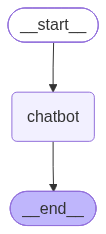

In [14]:
from IPython.display import Image, display
try:
  display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
  pass

In [ ]:
while True:
  user_input=input("User: ")
  if user_input.lower() in ["quit","q"]:
    print("Good Bye")
    break
  for event in graph.stream({'messages':("user",user_input)}):
    print(event.values())
    for value in event.values():
      print(value['messages'])
      print("Assistant:",value["messages"].content)

dict_values([{'messages': AIMessage(content='**Artificial Intelligence (AI)** is a field of computer science that focuses on creating intelligent machines that can think, learn, and act like humans. AI involves the development of algorithms, statistical models, and computer programs that enable machines to perform tasks that typically require human intelligence, such as:\n\n1. **Reasoning**: Drawing inferences, making decisions, and solving problems.\n2. **Learning**: Improving performance on a task over time, based on experience or data.\n3. **Perception**: Interpreting and understanding data from sensors, such as images, speech, or text.\n4. **Natural Language Processing (NLP)**: Understanding, generating, and processing human language.\n\nAI has many applications, including:\n\n1. **Virtual Assistants**: Siri, Google Assistant, Alexa\n2. **Image Recognition**: Self-driving cars, facial recognition, object detection\n3. **Predictive Maintenance**: Predicting equipment failures, sched